In [2]:
#import libraries 

In [3]:
import numpy as np #faster data preprocessing(arrays)

In [4]:
import pandas as pd #eda purpose

In [5]:
data = pd.read_csv('titanic.csv')

In [6]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [7]:
#understanding the data -->info(),describe(),columns(),unique(),value_count
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB


In [8]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [9]:
#we will seperate the columns
data.dtypes
data.select_dtypes(include='object')
data.select_dtypes(include=['int','float'])

C:\Users\nagha\AppData\Local\Temp\ipykernel_25492\2828472862.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include='object')


,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [10]:
#Total number of passengers in the ship
print('Total number of passengers in the ship are',len(data))

Total number of passengers in the ship are 891


In [11]:
#Statistical Distribution -->describe()
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
data.describe(include='object')
#top return most occuring value 
#freq returns the count of most occuring values

C:\Users\nagha\AppData\Local\Temp\ipykernel_25492\613194754.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [13]:
#we try to understand the unique values in the columns
data['sex'].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [14]:
data['survived'].unique()

array([0, 1])

In [15]:
data['embarked'].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [16]:
data['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [17]:
data['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [18]:
data['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [19]:
data['class'].value_counts();
data['class'].value_counts(ascending=True)

class
Second    184
First     216
Third     491
Name: count, dtype: int64

In [20]:
data['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [21]:
data['age'].value_counts()

age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [22]:
data['age'].value_counts().head(30)
#it returns the top samples by default it is 5

age
24.0    30
22.0    27
18.0    26
28.0    25
19.0    25
30.0    25
21.0    24
25.0    23
36.0    22
29.0    20
26.0    18
35.0    18
27.0    18
32.0    18
31.0    17
16.0    17
20.0    15
34.0    15
33.0    15
23.0    15
39.0    14
40.0    13
42.0    13
17.0    13
45.0    12
38.0    11
2.0     10
4.0     10
50.0    10
47.0     9
Name: count, dtype: int64

In [23]:
data.sample(15)
#it get random samples in data set

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
741,0,1,male,36.0,1,0,78.8500,S,First,man,True,C,Southampton,no,False
780,1,3,female,13.0,0,0,7.2292,C,Third,child,False,NaN,Cherbourg,yes,True
599,1,1,male,49.0,1,0,56.9292,C,First,man,True,A,Cherbourg,yes,False
590,0,3,male,35.0,0,0,7.1250,S,Third,man,True,NaN,Southampton,no,True
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
787,0,3,male,8.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
377,0,1,male,27.0,0,2,211.5000,C,First,man,True,C,Cherbourg,no,False
587,1,1,male,60.0,1,1,79.2000,C,First,man,True,B,Cherbourg,yes,False
168,0,1,male,NaN,0,0,25.9250,S,First,man,True,NaN,Southampton,no,True
867,0,1,male,31.0,0,0,50.4958,S,First,man,True,A,Southampton,no,True


In [24]:
#datavisualization -->matplotlib,seaborn,plotly
import matplotlib.pyplot as plt #!pip install matplotlib

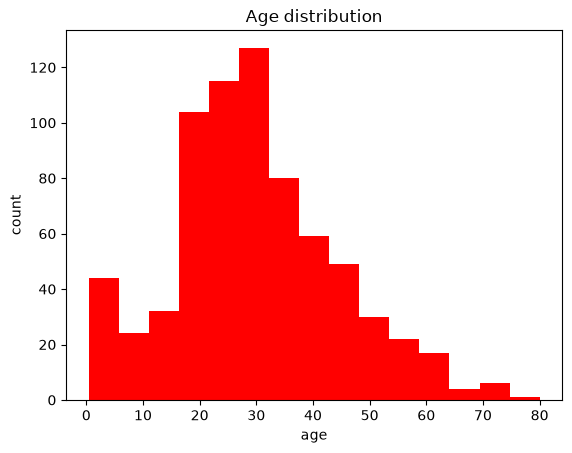

In [25]:
#distributed of age
plt.hist(data['age'],bins=15,color='red')
plt.xlabel("age")
plt.ylabel("count")
plt.title("Age distribution")
plt.show()

[ 44.  24.  32. 104. 115. 127.  80.  59.  49.  30.  22.  17.   4.   6.
   1.]
<BarContainer object of 15 artists>


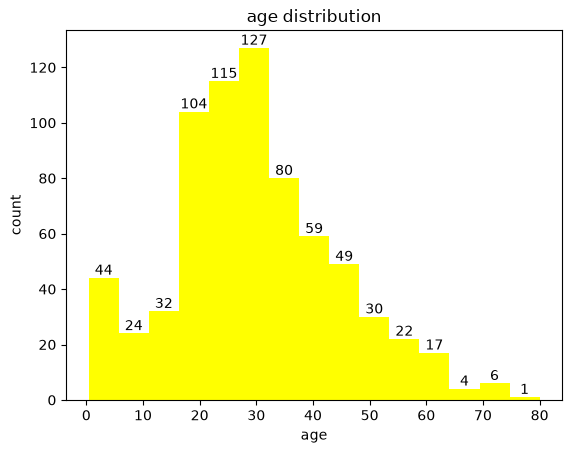

In [26]:
#distributed of age
counts,edges,bars=plt.hist(data['age'],bins=15,color='yellow')
print(counts)
print(bars)
plt.hist(data['age'],bins=15,color='yellow')
plt.xlabel("age")
plt.ylabel("count")
plt.bar_label(bars)
plt.title("age distribution")
plt.show()

<Axes: xlabel='sex'>

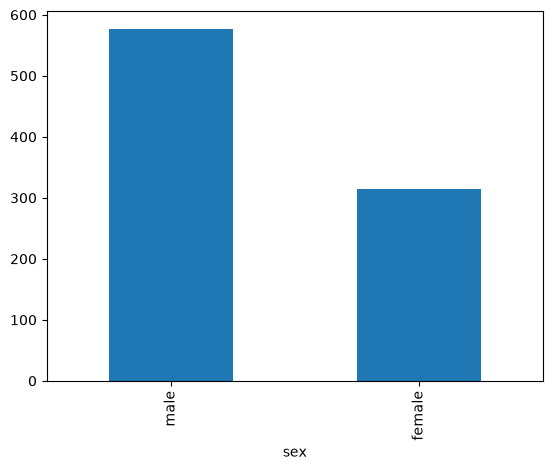

In [27]:
#bar plot representation
data['sex'].value_counts().plot(kind='bar')

<Axes: ylabel='class'>

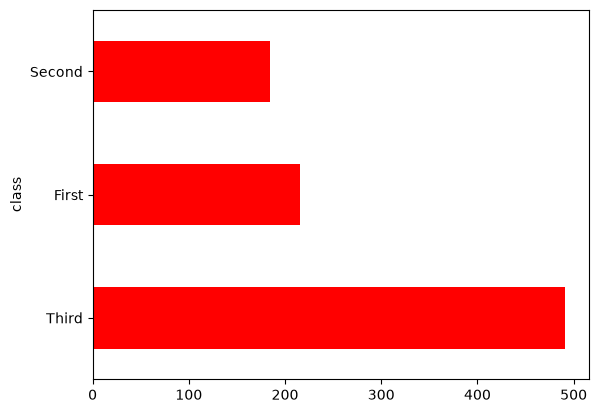

In [28]:
data['class'].value_counts().plot(kind='barh',color='red')

<Axes: ylabel='class'>

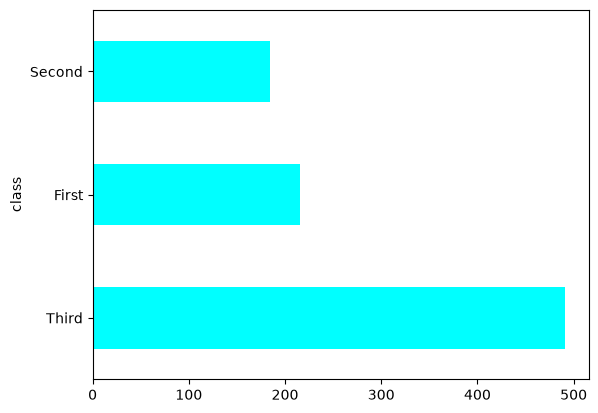

In [29]:
data['class'].value_counts().plot(kind='barh',color='cyan')

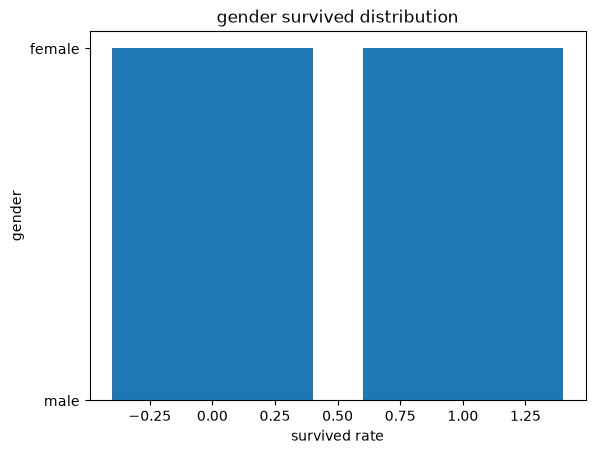

In [30]:
plt.bar(data['survived'],data['sex'])
plt.xlabel("survived rate")
plt.ylabel("gender")
plt.title("gender survived distribution")
plt.show()

In [31]:
data['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [32]:
#549 / (549+342)
index = data['survived'].value_counts().keys().tolist()
print(index)
labels = data['survived'].value_counts().values.tolist()
print(labels)

[0, 1]
[549, 342]


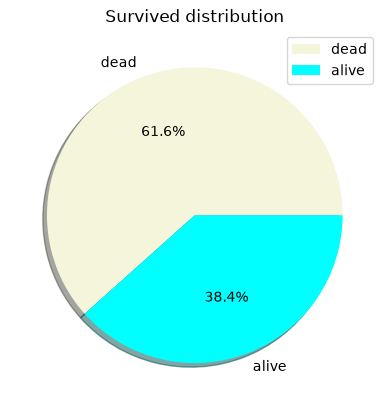

In [33]:
#Pie Chart 
plt.pie(x=labels,
        labels=['dead','alive'],
        colors=['beige','cyan'],
        autopct="%.1f%%",
        shadow=True)
plt.title("Survived distribution")
plt.legend()
plt.show()
        

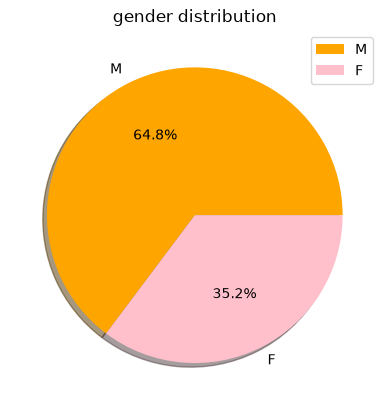

In [34]:
#Pie Chart 
plt.pie(x=[577,314],
        labels=['M','F'],
        colors=['orange','pink'],
        autopct="%.1f%%",
        shadow=True)
plt.title("gender distribution")
plt.legend()
plt.show()
        

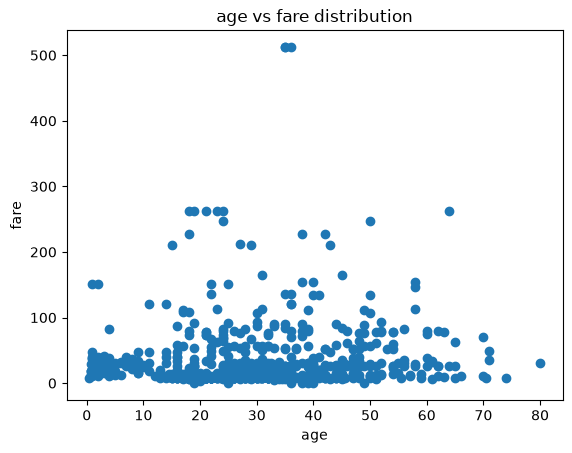

In [35]:
#pairwise relationship -->scatterplot()
plt.scatter(x=data['age'],
            y=data['fare'])
plt.xlabel("age")
plt.ylabel("fare")
plt.title("age vs fare distribution")
plt.show()

In [38]:
#pip install plotty 
import ploty

ModuleNotFoundError: No module named 'ploty'

In [37]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
pip install cufflinks

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import plotly as py
import plotly.graph_objects as go #for interactive graphs
from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected=True)

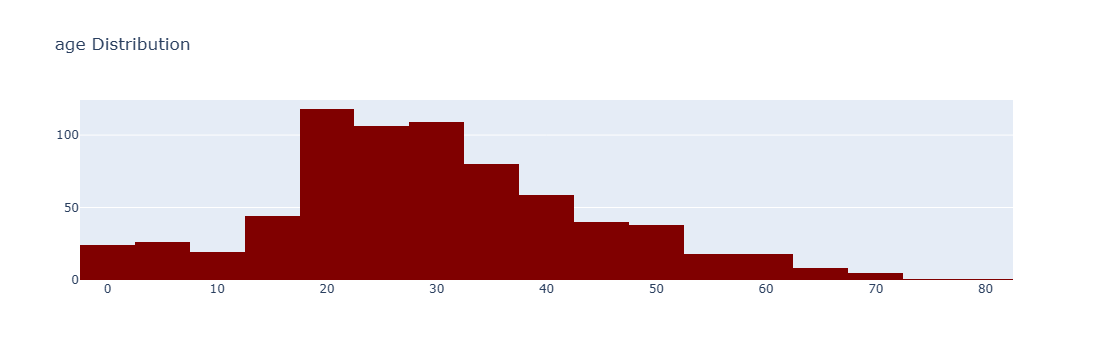

In [41]:
#Let's visualize histogram
trace = go.Histogram(x = data['age'],
                     nbinsx=20,
                     marker={'color':'maroon'})
#layout define for the graph
layout = go.Layout(title="age Distribution")
#we combine the trace with the layout to display the figure
fig = go.Figure(data=trace,layout = layout)
fig.show()

In [42]:
print(index)
print(labels)

[0, 1]
[549, 342]


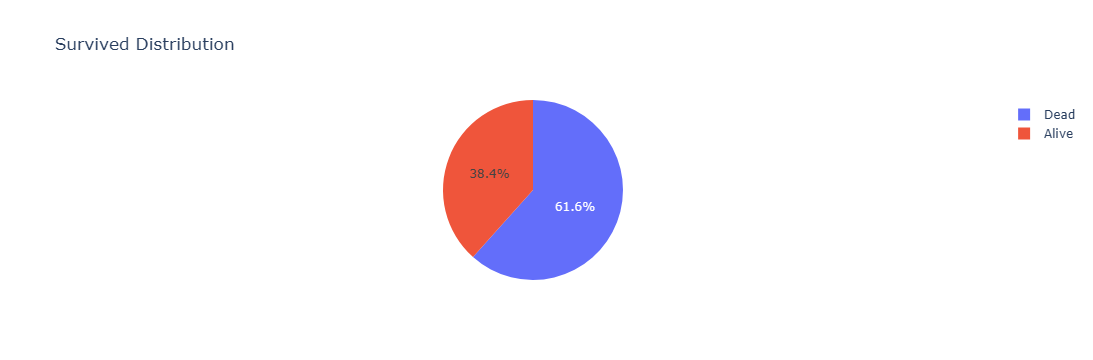

In [43]:
#Noe we will display for Piechart
trace = go.Pie(labels=['Dead','Alive'],
               values=[549,342],
              )
layout  = go.Layout(title = 'Survived Distribution')
fig = go.Figure(data=trace,layout=layout)
fig.show()

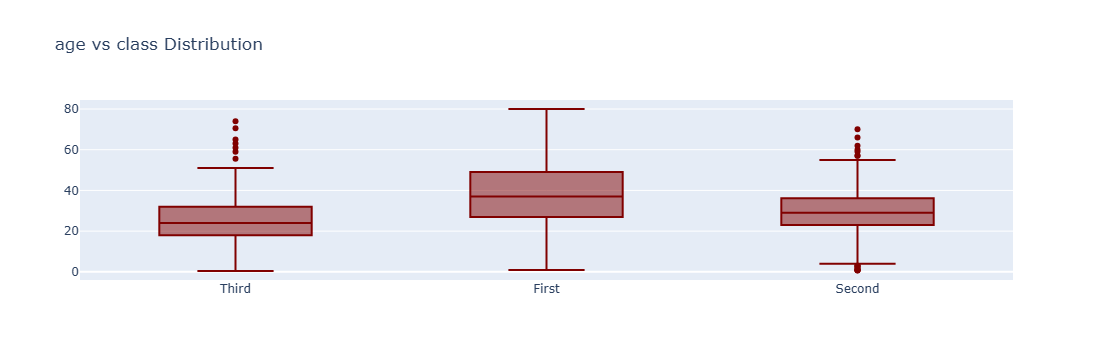

In [44]:
#Box plot and Scatter plot
trace = go.Box(x=data['class'],
               y=data['age'],
               marker={'color':'maroon'})
layout = go.Layout(title="age vs class Distribution")
fig = go.Figure(data=trace,layout = layout)
fig.show()

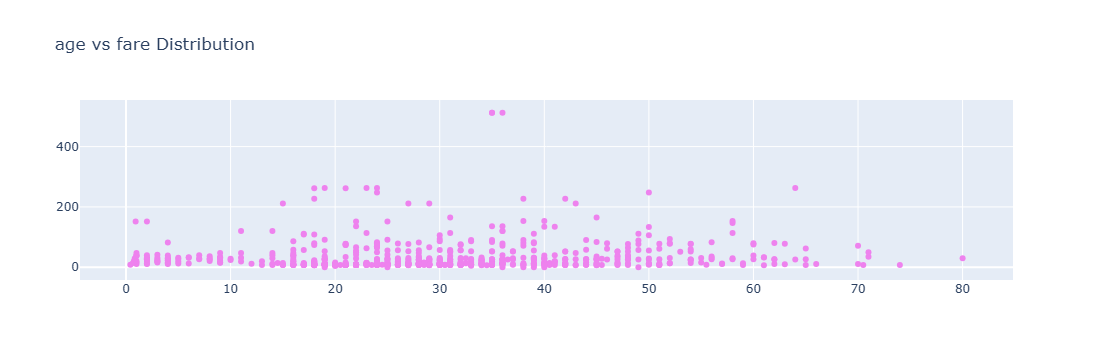

In [45]:
#Scatter Plot representation --> Age vs Fare
trace = go.Scatter(x=data['age'],y=data['fare'],
                   mode='markers',
                   marker={'color':'violet'})
layout = go.Layout(
    title="age vs fare Distribution")
fig = go.Figure(data=trace,layout = layout)
fig.show()

In [46]:
#Understanding the missing values and filling
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [47]:
print(data['age'].mean())

29.69911764705882


In [48]:
#We can fill the Age column missing values with mean
data['age'] = data['age'].fillna(data['age'].mean(),inplace=True);
data.isnull().sum()

C:\Users\nagha\AppData\Local\Temp\ipykernel_25492\3673704774.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['age'] = data['age'].fillna(data['age'].mean(),inplace=True);


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [49]:
data['embarked']=data['embarked'].fillna("s",inplace=True)

C:\Users\nagha\AppData\Local\Temp\ipykernel_25492\80014584.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['embarked']=data['embarked'].fillna("s",inplace=True)


In [50]:
#get_dummies()
pclass=pd.get_dummies(data['pclass'],
                      drop_first=True,
                      dtype=int)
pclass

,2,3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1
...,...,...
886,1,0
887,0,0
888,0,1
889,0,0


In [51]:
data.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,29.699118,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.000000,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.000000,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.000000,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.000000,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [52]:
#get_dummies()
embark=pd.get_dummies(data['embarked'],drop_first=True,dtype=int)
embark

,Q,S,s
0,0,1,0
1,0,0,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
886,0,1,0
887,0,1,0
888,0,1,0
889,0,0,0


In [53]:
sex=pd.get_dummies(data['sex'],drop_first=True,dtype=int)
sex

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [54]:
#concatenation of all tables
final_data=pd.concat([data,pclass,sex,embark],axis=1)
final_data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,deck,embark_town,alive,alone,2,3,male,Q,S,s
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,...,NaN,Southampton,no,False,0,1,1,0,1,0
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,...,C,Cherbourg,yes,False,0,0,0,0,0,0
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,...,NaN,Southampton,yes,True,0,1,0,0,1,0
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,...,C,Southampton,yes,False,0,0,0,0,1,0
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,...,NaN,Southampton,no,True,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,...,NaN,Southampton,no,True,1,0,1,0,1,0
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,...,B,Southampton,yes,True,0,0,0,0,1,0
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,...,NaN,Southampton,no,False,0,1,0,0,1,0
889,1,1,male,26.000000,0,0,30.0000,C,First,man,...,C,Cherbourg,yes,True,0,0,1,0,0,0


In [56]:
final_data.columns

Index([   'survived',      'pclass',         'sex',         'age',
             'sibsp',       'parch',        'fare',    'embarked',
             'class',         'who',  'adult_male',        'deck',
       'embark_town',       'alive',       'alone',             2,
                   3,        'male',           'Q',           'S',
                 's'],
      dtype='object')

In [57]:
final_data.drop(
    columns=['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'],
    inplace=True,
    errors='ignore'
)

In [58]:
final_data.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,2,3,male,Q,S,s
0,0,3,22.0,1,0,7.2500,True,False,0,1,1,0,1,0
1,1,1,38.0,1,0,71.2833,False,False,0,0,0,0,0,0
2,1,3,26.0,0,0,7.9250,False,True,0,1,0,0,1,0
3,1,1,35.0,1,0,53.1000,False,False,0,0,0,0,1,0
4,0,3,35.0,0,0,8.0500,True,True,0,1,1,0,1,0


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,StratifiedKFold,StratifiedShuffleSplit,cross_val_score
from sklearn.metrics import (
             accuracy_score,precision_score,recall_score,
             confusion_matrix , classification_report,roc_curve,ConfusionMatrixDisplay)

In [60]:
#Loading the data
model_data = final_data.copy()
#model_data
#model_data.info()

In [62]:
model_data.columns = model_data.columns.astype(str)
X = model_data.drop(columns='survived')
Y = model_data['survived'].astype(int)
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      891 non-null    int64  
 1   age         891 non-null    float64
 2   sibsp       891 non-null    int64  
 3   parch       891 non-null    int64  
 4   fare        891 non-null    float64
 5   adult_male  891 non-null    bool   
 6   alone       891 non-null    bool   
 7   2           891 non-null    int64  
 8   3           891 non-null    int64  
 9   male        891 non-null    int64  
 10  Q           891 non-null    int64  
 11  S           891 non-null    int64  
 12  s           891 non-null    int64  
dtypes: bool(2), float64(2), int64(9)
memory usage: 78.4 KB


In [66]:
print("Input Shape:",X.shape)
print("Output Shape:",Y.shape)

Input Shape: (891, 13)
Output Shape: (891,)


In [67]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)
logistic_model=Pipeline([
    ("scale",StandardScaler()),
    ("classifier",LogisticRegression(max_iter=1000,random_state=42))])
logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_

In [76]:
# start buliding the model
logistic_model.fit(X_train,Y_train)
logistic_model_prob = logistic_model.predict_proba(X_test)[:,1]
logistic_predictions = logistic_model.predict(X_test)
print(logistic_model_prob[:10])
print(logistic_predictions[:10])

[0.0499565  0.0657995  0.11445964 0.03407881 0.73362362 0.56768751
 0.7912728  0.31298303 0.33714728 0.17060197]
[0 0 0 0 1 1 1 0 0 0]


In [71]:
print(confusion_matrix(Y_test,logistic_predictions))

[[98 12]
 [18 51]]


In [77]:
logistic_model_prob.shape

(179,)

In [78]:
(98+46) / 179
#Precision = TP / TP + FP
#recall = TP / TP + FN

0.8044692737430168

In [79]:
print(classification_report(Y_test,logistic_predictions))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [83]:
from sklearn.metrics import f1_score,roc_auc_score

In [84]:
#let's create an evaluate function
def evaluate_model(name,Y_true,prediction,probability):
    """Evaluation Function for metrics"""
    tn,fp,fn,tp = confusion_matrix(Y_true,prediction,labels=[0,1]).ravel()
    return {
    'Model_Name':name,
    'Accuracy':accuracy_score(Y_true,prediction),
    'Precision':precision_score(Y_true,prediction,zero_division=0),
    'Recall':recall_score(Y_true,prediction,zero_division=0),
    'Specificity':tn / (tn + fp),
    'F1-Score':f1_score(Y_true,prediction,zero_division=0),
    'ROC-AUC':roc_auc_score(Y_true,probability),
    'TN':tn,"FP":fp,"TP":tp,"FN":fn}
logistic_metrics = evaluate_model("Logistic Regression",
                                  Y_test,
                                  logistic_predictions,
                                  logistic_model_prob)
logistic_metrics

{'Model_Name': 'Logistic Regression',
 'Accuracy': 0.8324022346368715,
 'Precision': 0.8095238095238095,
 'Recall': 0.7391304347826086,
 'Specificity': np.float64(0.8909090909090909),
 'F1-Score': 0.7727272727272727,
 'ROC-AUC': 0.8696969696969697,
 'TN': np.int64(98),
 'FP': np.int64(12),
 'TP': np.int64(51),
 'FN': np.int64(18)}

In [88]:
confusion_matrix

<function sklearn.metrics._classification.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)>

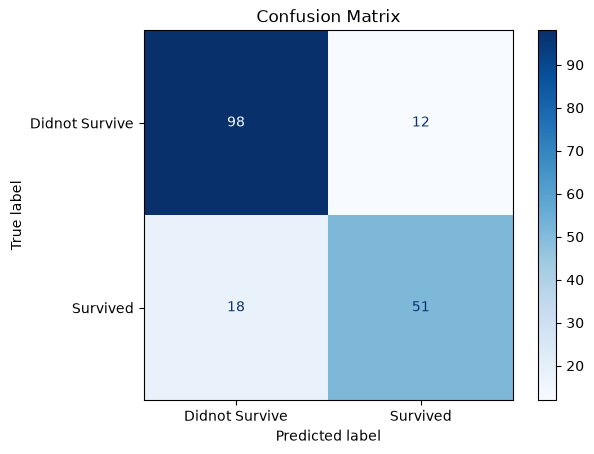

In [89]:
ConfusionMatrixDisplay.from_predictions(Y_test,logistic_predictions,cmap='Blues',
                                        display_labels=['Didnot Survive','Survived'])
plt.title("Confusion Matrix")
plt.show()

In [91]:
#We will check the best model(Logistic,Random Forest,Desicion Tree)by
#performing validation and then will get the best model ...
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree":DecisionTreeClassifier(max_depth=5,
                                           min_samples_leaf=8,random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150,
                                            min_samples_leaf=3,
                                            random_state=42,n_jobs=-1)}
test_outputs = {}
metric_rows = []
for name,model in models.items():
    model.fit(X_train,Y_train)
    probability=model.predict_proba(X_test)[:,1]
    prediction=model.predict(X_test)
    test_outputs[name] = {
        'probability':probability,
        'prediction':prediction}
    metric_rows.append(evaluate_model(name,Y_test,prediction,probability))
holdout_metrics = pd.DataFrame(metric_rows)
holdout_metrics

,Model_Name,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC,TN,FP,TP,FN
0,Logistic Regression,0.832402,0.809524,0.739130,0.890909,0.772727,0.869697,98,12,51,18
1,Decision Tree,0.804469,0.803571,0.652174,0.900000,0.720000,0.843083,99,11,45,24
2,Random Forest,0.810056,0.807018,0.666667,0.900000,0.730159,0.855995,99,11,46,23
